In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
#Reading data
data= pd.read_csv("clustering_data.csv")
data.head()
#Filtering data by checking if Latitude and Longitude have any symbols other than {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, ., -} and replacing it with empty string
data['Latitude'] = data['Latitude'].astype(str).str.replace('[^0-9.-]', '', regex=True) 
data['Longitude'] = data['Longitude'].astype(str).str.replace('[^0-9.-]', '', regex=True)
data['Latitude'] = data['Latitude'].str.replace(r'(\d+\.?\d*)-$', r'-\1', regex=True)
data['Longitude'] = data['Longitude'].str.replace(r'(\d+\.?\d*)-$', r'-\1', regex=True)

C:\Users\jaksh\AppData\Local\Temp\ipykernel_30016\1099362619.py:2: DtypeWarning: Columns (0: Latitude) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv("clustering_data.csv")


In [35]:
#Removing outliers(due to error) by manually putting latitude and longitudes of Jharkhand
filtered_data= data.loc[(data['StateName']=='JHARKHAND') &(data['Latitude'].astype(float)>=21 ) & (data['Latitude'].astype(float)<=26) &(data['Longitude'].astype(float)>=83) &(data['Longitude'].astype(float)<=88)].dropna()
filtered_data = filtered_data.reset_index(drop=True)
filtered_data.head(5)

,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
0,Jharkhand Circle,DivReportingCircle,Santhal Parganas Division,Gokula BO,815352,BO,Delivery,JAMTARA,JHARKHAND,24.043125,86.616147
1,Jharkhand Circle,DivReportingCircle,Santhal Parganas Division,Bapugram BO,814165,BO,Delivery,GODDA,JHARKHAND,24.49885,86.67075
2,Jharkhand Circle,DivReportingCircle,Santhal Parganas Division,Bharta Chak BO,814154,BO,Delivery,GODDA,JHARKHAND,25.09314,87.38382
3,Jharkhand Circle,DivReportingCircle,Santhal Parganas Division,Dighi BO,814154,BO,Delivery,GODDA,JHARKHAND,25.09314,87.38382
4,Jharkhand Circle,DivReportingCircle,Santhal Parganas Division,Ghoothi BO,814154,BO,Delivery,GODDA,JHARKHAND,25.0255115,87.3189995


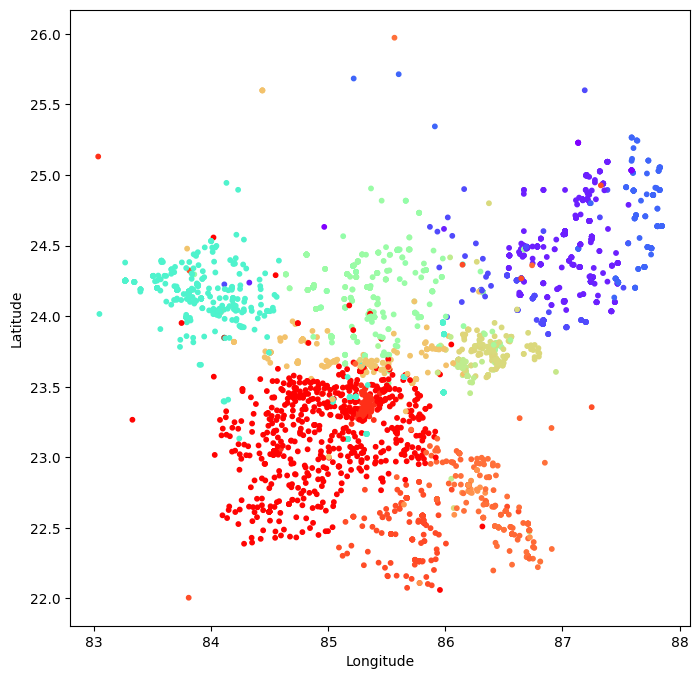

In [36]:
#Plotting data with each place with same pincode having same color
filtered_data['Longitude'] = filtered_data['Longitude'].astype(float)
filtered_data['Latitude'] = filtered_data['Latitude'].astype(float)

plt.figure(figsize=(8, 8))
plt.scatter(filtered_data['Longitude'], filtered_data['Latitude'], c=filtered_data["Pincode"],cmap="rainbow",s=10)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [37]:
#Gives k random initial points for centroids
def initialize_pts(X, k):
    indices = np.random.choice(len(X), size=k, replace=False)
    return X[indices]
    

In [38]:
#Separates the dataset into k clusters(closest centroid to each point)
def assign_clusters(X, centroids):
    distances = []
    for point in X:
        d = []
        for c in centroids:
            dist = np.linalg.norm(point - c)
            d.append(dist)
        distances.append(d)
    distances = np.array(distances)
    labels = np.argmin(distances, axis=1)
    return labels
    

In [39]:
#Centroids now become the mean of all the points in the same cluster
def update_centroids(X, labels, k):
    new_centroids = []
    for i in range(k):
        points = X[labels == i]   # select points in cluster i
        
        if len(points) == 0:  # handle empty cluster
            new_centroids.append(X[np.random.randint(len(X))])
        else:
            new_centroids.append(points.mean(axis=0))
    
    return np.array(new_centroids)

In [40]:
#Gives variance for all points from respective centroids
def variance(X, labels, centroids):
    var = 0
    for j in range(len(centroids)):
        points = X[labels == j]
        var += np.sum((points - centroids[j])**2)
    return var


def kmeans(filtered_data, k, max_iters=100, n_init=5):
    best_labels = None
    best_centroids = None
    best_var = float('inf')
    X = filtered_data[['Longitude', 'Latitude']].values.astype(float)

    for i in range(n_init):
        centroids = initialize_pts(X, k)

        for j in range(max_iters):
            labels = assign_clusters(X, centroids)
            new_centroids = update_centroids(X, labels, k)

            if np.allclose(centroids, new_centroids):
                break

            centroids = new_centroids

        # compute how good this run is
        var = variance(X, labels, centroids)

        # keep the best one
        if var < best_var:
            best_var = var
            best_labels = labels
            best_centroids = centroids

    return best_labels, best_centroids

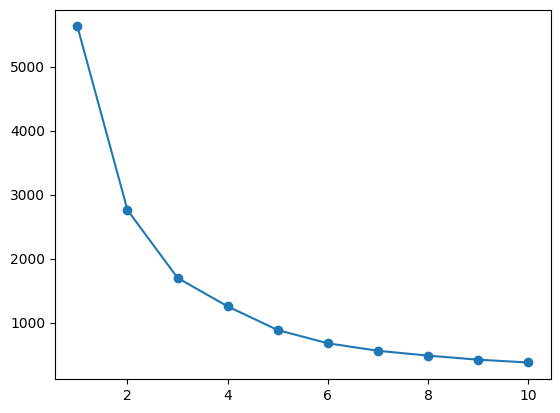

In [41]:
#Making elbow graph to find best k
k=[1,2,3,4,5,6,7,8,9,10]
varList=[]
for i in k:
    var=0
    best_labels, best_centroids= kmeans(filtered_data, i)
    X = filtered_data[['Longitude', 'Latitude']].values.astype(float)
    for j in range(i):
        points= X[best_labels==j]
        for poi in points:
            var+=np.linalg.norm(poi-best_centroids[j])**2
    varList.append(var)
plt.plot(k, varList, marker='o')    
labels, centroids = kmeans(filtered_data, k=6)

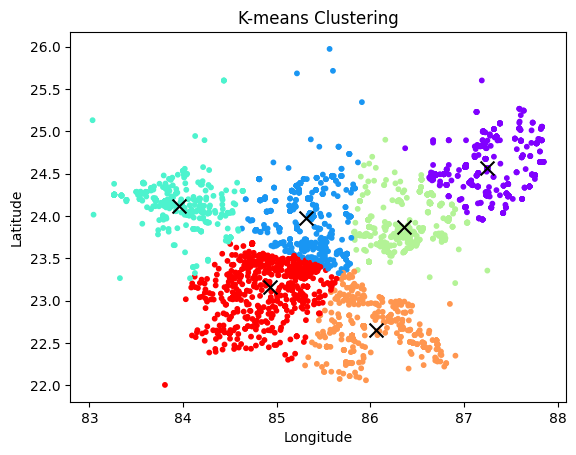

In [42]:
#Plotting the kmeans model
plt.scatter(filtered_data['Longitude'], filtered_data['Latitude'],
c=labels, cmap='rainbow', s=10)

plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', s=100, marker='x')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-means Clustering")
plt.show()

In [ ]:
"""As we can see from the elbow graph, Jharkhand is divided into about 6 different dense regions.
Finding the centroid for each cluster may be useful in activities such as devivery where its easier to deliver goods from centroid to
any point in the cluster."""